# Power Generation Time-Series — Reference Solution

Hourly generation by source (`power_generation.csv`), ~2 years (2018–2019), MW.
Covers **Part 1 (Q1 trends/seasonality, Q2 Solar distribution, Q3 pumped-storage)**
and **Part 2 (predict Thermal under the lag constraint)**.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scipy.stats as st
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('power_generation.csv', parse_dates=['datetime']).set_index('datetime')

# --- data cleaning: sentinel & missing values flagged in the brief ---
df['Wind'] = df['Wind'].replace(-999, np.nan)          # bad sentinel
df[['Solar','Wind']] = df[['Solar','Wind']].interpolate('time')  # short gaps
print(df.shape); df.head(3)

(17520, 9)


,Thermal,Nuclear,Wind,Solar,Water,PumpedStorage,Thermal_Coal,Thermal_Gas,Thermal_Rubbish
datetime,,,,,,,,,
2018-01-01 00:00:00,"22,966.70","6,930.30","5,636.40",0.00,"2,522.20",595.50,"12,019.40","9,904.30","1,043.00"
2018-01-01 01:00:00,"21,968.30","6,933.50","6,144.50",0.00,"2,805.20",346.30,"10,559.60","10,473.40",935.30
2018-01-01 02:00:00,"22,250.00","7,090.30","6,611.20",0.00,"2,669.90",-63.90,"11,675.70","9,828.90",745.40


## Part 1 — Q1: generation by source, trends & seasonality

Mean MW by source:
Thermal         20,434.00
Nuclear          6,945.00
Wind             3,880.00
Solar              209.00
Water            2,799.00
PumpedStorage     -310.00


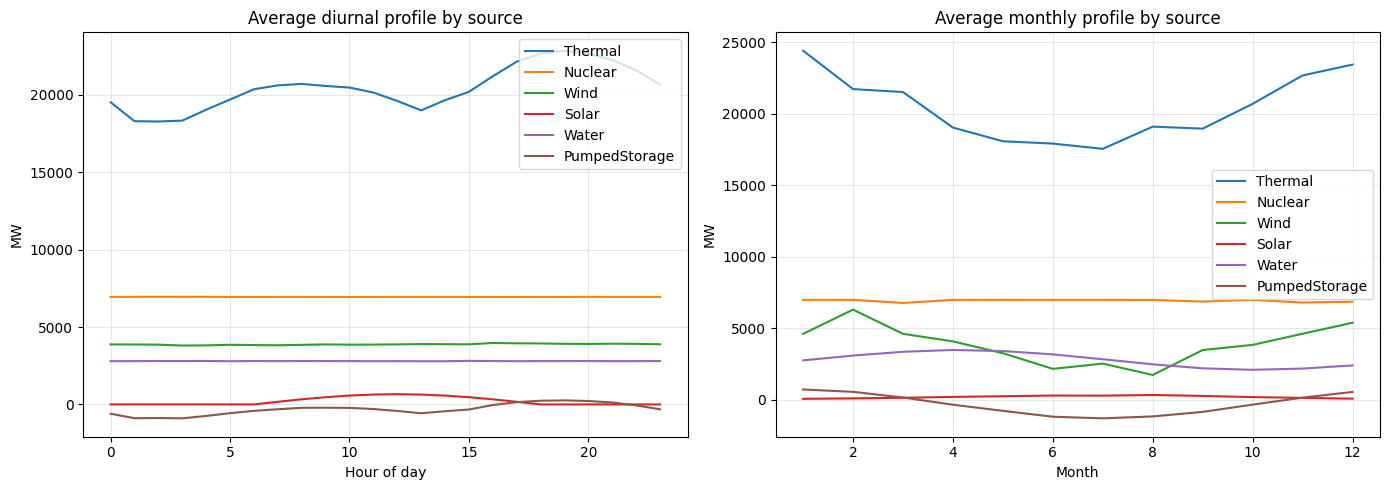

In [2]:
sources = ['Thermal','Nuclear','Wind','Solar','Water','PumpedStorage']
print('Mean MW by source:'); print(df[sources].mean().round(0).to_string())

# (a) average diurnal profile per source
hourly = df.groupby(df.index.hour)[sources].mean()
# (b) average monthly profile per source (seasonality)
monthly = df.groupby(df.index.month)[sources].mean()

fig, ax = plt.subplots(1,2, figsize=(14,5))
hourly.plot(ax=ax[0]); ax[0].set_title('Average diurnal profile by source')
ax[0].set_xlabel('Hour of day'); ax[0].set_ylabel('MW'); ax[0].grid(alpha=.3)
monthly.plot(ax=ax[1]); ax[1].set_title('Average monthly profile by source')
ax[1].set_xlabel('Month'); ax[1].set_ylabel('MW'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Read-out.** Each source has a distinct signature:
- **Nuclear** — flat baseload, no diurnal or seasonal shape (dips are maintenance outages).
- **Wind** — no diurnal cycle but strong *winter* seasonality and high volatility (weather-driven).
- **Solar** — sharp diurnal bell (zero at night, midday peak), stronger in *summer*.
- **Thermal** — load-follows: tracks the daily demand peaks and winter heating.
- **Water** (run-of-river) — mild spring-melt seasonality.
- **PumpedStorage** — see Q3 (twice-daily charge/discharge).

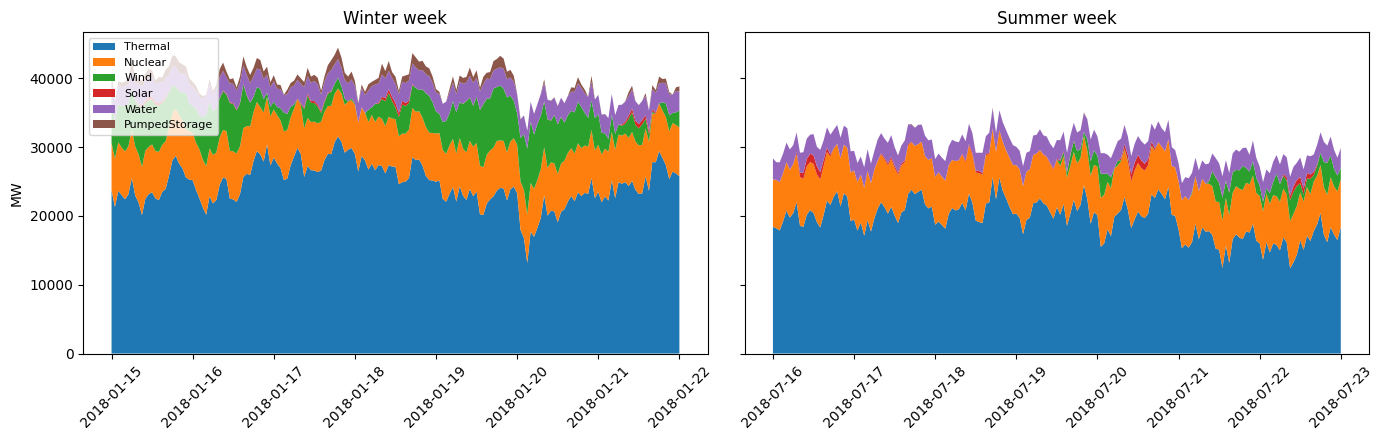

In [3]:
# stacked generation mix on a sample winter week vs summer week
fig, ax = plt.subplots(1,2, figsize=(14,4.5), sharey=True)
for a,(lab,wk) in zip(ax, [('Winter week','2018-01-15'),('Summer week','2018-07-16')]):
    s = df.loc[wk: pd.Timestamp(wk)+pd.Timedelta(days=7), sources].clip(lower=0)
    a.stackplot(s.index, [s[c] for c in sources], labels=sources)
    a.set_title(lab); a.tick_params(axis='x', rotation=45)
ax[0].legend(loc='upper left', fontsize=8); ax[0].set_ylabel('MW')
plt.tight_layout(); plt.show()

## Part 1 — Q2: Solar daily generation & normality

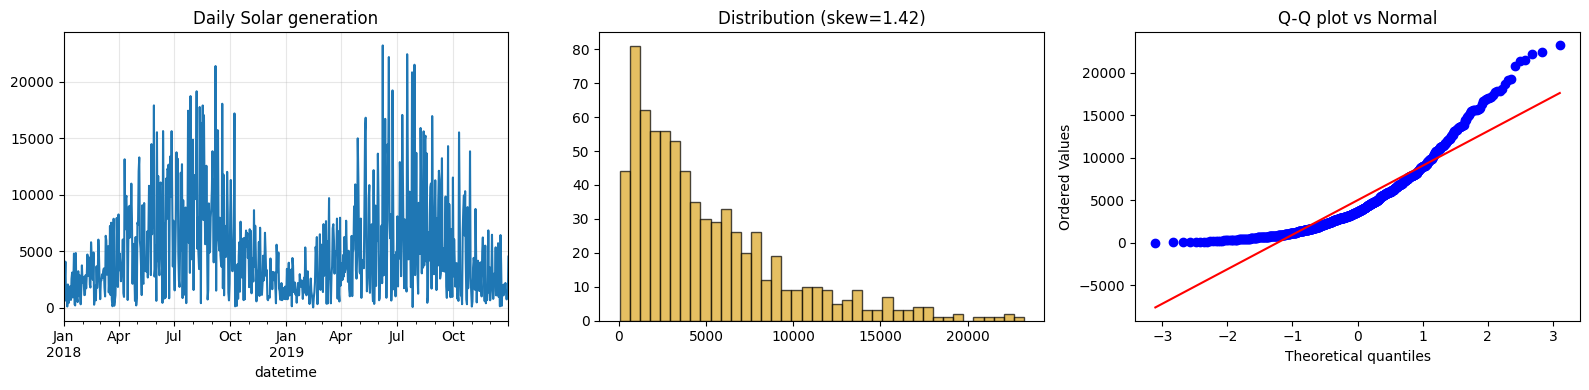

Shapiro-Wilk: W=0.865, p=1.52e-24  -> reject normality


In [4]:
daily_solar = df['Solar'].resample('D').sum().rename('solar_MWh')
daily_solar = daily_solar[daily_solar > 0]   # drop any all-missing days

fig, ax = plt.subplots(1,3, figsize=(16,4))
daily_solar.plot(ax=ax[0]); ax[0].set_title('Daily Solar generation'); ax[0].grid(alpha=.3)
ax[1].hist(daily_solar, bins=40, color='goldenrod', edgecolor='k', alpha=.7)
ax[1].set_title(f'Distribution (skew={st.skew(daily_solar):.2f})')
st.probplot(daily_solar, dist='norm', plot=ax[2]); ax[2].set_title('Q-Q plot vs Normal')
plt.tight_layout(); plt.show()

# formal normality test
W, p = st.shapiro(daily_solar.sample(min(2000,len(daily_solar)), random_state=0))
print(f'Shapiro-Wilk: W={W:.3f}, p={p:.2e}  -> {"reject" if p<0.05 else "fail to reject"} normality')

**Is it normal?** No. Daily solar is **right-skewed** (skew > 1): a hard floor at zero,
many cloudy/overcast low-output days, and a ceiling set by clear-sky days. The Q-Q plot bends
off the line in both tails and Shapiro-Wilk rejects normality decisively. There is also clear
**annual seasonality** (summer >> winter) and no long-term trend.

skew raw    = 1.423
skew sqrt   = 0.500
skew Box-Cox= -0.039   (lambda=0.250)


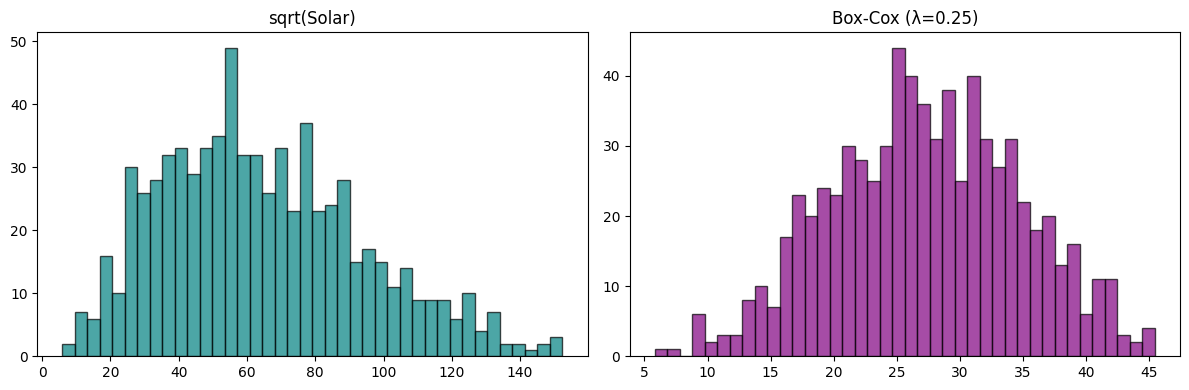

In [5]:
# Making it closer to normal: variance-stabilising transforms
sqrt_t = np.sqrt(daily_solar)
boxcox_t, lam = st.boxcox(daily_solar + 1)   # +1 guards against zeros
print(f'skew raw    = {st.skew(daily_solar):.3f}')
print(f'skew sqrt   = {st.skew(sqrt_t):.3f}')
print(f'skew Box-Cox= {st.skew(boxcox_t):.3f}   (lambda={lam:.3f})')

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].hist(sqrt_t, bins=40, color='teal', edgecolor='k', alpha=.7); ax[0].set_title('sqrt(Solar)')
ax[1].hist(boxcox_t, bins=40, color='purple', edgecolor='k', alpha=.7); ax[1].set_title(f'Box-Cox (λ={lam:.2f})')
plt.tight_layout(); plt.show()

**How to make it normal.** A concave, variance-stabilising transform pulls in the right tail.
`sqrt` already roughly halves the skew; **Box-Cox** (fitted λ) does best, bringing skew near 0.
Note the deseasonalised series (e.g. dividing by a monthly climatology) before transforming would
help further, since some of the spread is seasonal rather than purely distributional.

## Part 1 — Q3: pumped-storage (“dump”) by hour

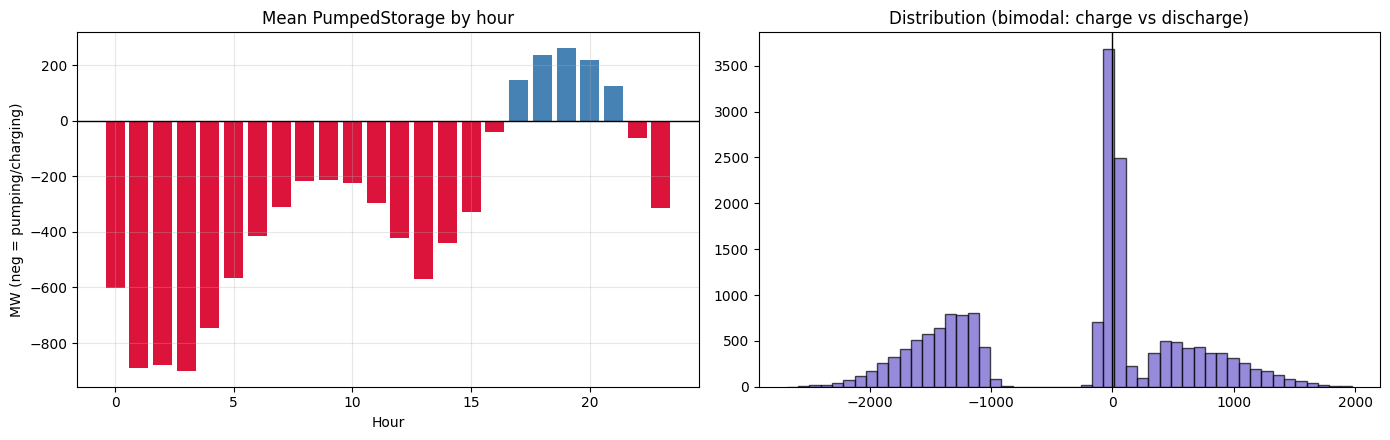

Charging hours (most negative): [3, 1, 2]
Generating hours (most positive): [19, 18, 20]
Pumping share of hours: 55.2%  | energy ~ net -5,433,213 MWh (round-trip loss)


In [6]:
ps = df['PumpedStorage']
by_hour = ps.groupby(ps.index.hour).agg(['mean','std'])

fig, ax = plt.subplots(1,2, figsize=(14,4.5))
ax[0].bar(by_hour.index, by_hour['mean'],
          color=np.where(by_hour['mean']<0,'crimson','steelblue'))
ax[0].axhline(0,color='k',lw=1); ax[0].set_title('Mean PumpedStorage by hour')
ax[0].set_xlabel('Hour'); ax[0].set_ylabel('MW (neg = pumping/charging)'); ax[0].grid(alpha=.3)
ax[1].hist(ps, bins=50, color='slateblue', edgecolor='k', alpha=.7)
ax[1].axvline(0,color='k',lw=1); ax[1].set_title('Distribution (bimodal: charge vs discharge)')
plt.tight_layout(); plt.show()

print('Charging hours (most negative):', by_hour['mean'].nsmallest(3).index.tolist())
print('Generating hours (most positive):', by_hour['mean'].nlargest(3).index.tolist())
print(f'Pumping share of hours: {(ps<0).mean():.1%}  | energy ~ net {ps.sum():,.0f} MWh (round-trip loss)')

**Properties.** Pumped storage is a *net consumer* of energy — it shows **negative** values
when pumping (charging) in the cheap overnight trough (hours ~1–3) and **positive** values when
generating into the evening price peak (hours ~18–20). The distribution is **bimodal** around zero,
and net energy over time is negative (round-trip efficiency loss). It is an arbitrage/storage asset,
not a primary generator — so it should be treated separately from supply-side sources in modelling.

## Part 2 — Predicting Thermal under the lag constraint

**Constraint.** Predict `Thermal[t]` using **contemporaneous** Wind and Solar (known/forecastable
at t), but only **lag-1** values of the other sources (Nuclear, Water, PumpedStorage) plus lagged
Thermal itself. Calendar features (hour, month, weekend) are known at t and allowed.

This mirrors a realistic dispatch setting: renewable nowcasts are available, but other plants'
output is only known with a delay, so they enter lagged.

In [7]:
d = df.copy()
# contemporaneous renewables
feat = pd.DataFrame(index=d.index)
feat['Wind_t']  = d['Wind']
feat['Solar_t'] = d['Solar']
# lag-1 of the constrained sources + lagged target
for c in ['Nuclear','Water','PumpedStorage','Thermal']:
    feat[f'{c}_lag1'] = d[c].shift(1)
# calendar (known at t)
feat['hour']    = d.index.hour
feat['month']   = d.index.month
feat['weekend'] = (d.index.dayofweek >= 5).astype(int)
feat['Thermal'] = d['Thermal']
feat = feat.dropna()

# time-ordered split: last ~6 months as test (no shuffling for time series)
split = feat.index < '2019-07-01'
train, test = feat[split], feat[~split]
Xcols = [c for c in feat.columns if c != 'Thermal']
print('train', train.shape, '| test', test.shape)
print('features:', Xcols)

train (13103, 10) | test (4416, 10)
features: ['Wind_t', 'Solar_t', 'Nuclear_lag1', 'Water_lag1', 'PumpedStorage_lag1', 'Thermal_lag1', 'hour', 'month', 'weekend']


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

Xtr, ytr = train[Xcols], train['Thermal']
Xte, yte = test[Xcols],  test['Thermal']

models = {'Linear': LinearRegression(),
          'GBM': GradientBoostingRegressor(n_estimators=400, max_depth=3,
                                           learning_rate=0.05, random_state=0)}
preds = {}
for name,m in models.items():
    m.fit(Xtr,ytr); p = m.predict(Xte); preds[name]=p
    print(f'{name:7s} test R2={r2_score(yte,p):.3f}  MAE={mean_absolute_error(yte,p):,.0f} MW')

# baseline: persistence (Thermal_lag1)
print(f'{"Persist":7s} test R2={r2_score(yte, test["Thermal_lag1"]):.3f}  '
      f'MAE={mean_absolute_error(yte, test["Thermal_lag1"]):,.0f} MW')

Linear  test R2=0.843  MAE=1,290 MW


GBM     test R2=0.901  MAE=1,011 MW
Persist test R2=0.819  MAE=1,372 MW


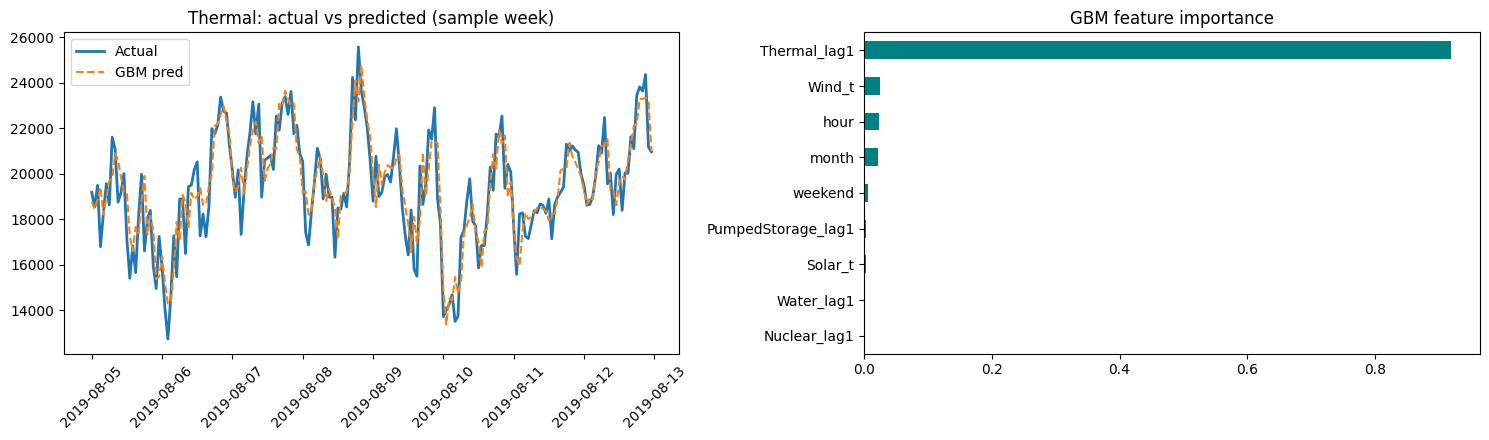

In [9]:
# diagnostics: fit over a sample test week + GBM importances
fig, ax = plt.subplots(1,2, figsize=(15,4.5))
wk = slice('2019-08-05','2019-08-12')
ax[0].plot(yte[wk].index, yte[wk], label='Actual', lw=2)
ax[0].plot(yte[wk].index, pd.Series(preds['GBM'], index=yte.index)[wk], '--', label='GBM pred')
ax[0].set_title('Thermal: actual vs predicted (sample week)'); ax[0].legend(); ax[0].tick_params(axis='x',rotation=45)

imp = pd.Series(models['GBM'].feature_importances_, index=Xcols).sort_values()
imp.plot.barh(ax=ax[1], color='teal'); ax[1].set_title('GBM feature importance')
plt.tight_layout(); plt.show()

### Discussion (Part 2)

**Why these features.** Thermal load-follows the demand the other sources don't cover, so the
strongest predictors are the **contemporaneous renewables** (`Wind_t`, `Solar_t`) — when they are
high, thermal backs off — together with **calendar** terms (hour/month/weekend) that proxy demand,
and **lagged Thermal** for persistence.

**Respecting the constraint.** Wind and Solar enter at time *t*; Nuclear/Water/PumpedStorage and
Thermal itself enter only at lag-1. The train/test split is **time-ordered** (no shuffling), and the
persistence baseline (`Thermal_lag1`) is the honest bar any model must beat.

**Evaluation.** Report R²/MAE on the held-out last 6 months. The GBM captures the non-linear
renewable→thermal offset; the linear model is the interpretable baseline. Residuals concentrate at
sharp ramp hours, the genuine difficulty in load-following.

**Extensions:** add weather/temperature (demand driver), holiday calendar, Fourier terms for the
daily/annual cycles, and model the renewable *nowcast error* explicitly rather than assuming perfect t.